# Rapport métier — Insights prédictifs pour la stratégie de recouvrement (Geldium, partie 3)

Ce notebook prépare le rapport destiné au responsable du recouvrement de Geldium à partir de l'EDA (partie 1) et du plan de modèle (partie 2) :

1. Résumé des insights prédictifs
2. Cadre de recommandation SMART
3. Considérations éthiques et IA responsable
4. Rapport de deux pages (`Business_Report_Geldium.docx`)

---
## Étape 1 — Résumé des insights prédictifs

### Prompts GenAI utilisés
- « Résume les principaux prédicteurs de la délinquance client à partir de l'analyse du jeu de données. »
- « Identifie les segments de clients ayant le plus grand risque de défaillance et explique pourquoi. »
- « Reformule ces résultats en langage simple pour un responsable du recouvrement non technique. »

### 1.1 Taux de délinquance par segment
Pour chaque segment : le taux de délinquance, son intervalle de confiance à 95 % (méthode de Wilson) et le *lift*, c'est-à-dire le rapport au taux moyen de 16 %. Un lift de 1,8 signifie un risque 1,8 fois supérieur à la moyenne.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.stats.proportion import proportion_confint

TARGET = "Delinquent_Account"
df = pd.read_csv("../Delinquency_prediction_cleaned.csv")
base = df[TARGET].mean()

segments = {
    "Comptes de moins d'un an": df.Account_Tenure == 0,
    "Carte Business + sans emploi": (df.Credit_Card_Type == "Business") & (df.Employment_Status == "Unemployed"),
    "Carte Business": df.Credit_Card_Type == "Business",
    "Sans emploi": df.Employment_Status == "Unemployed",
    "Ratio dette/revenu > 0,4": df.Debt_to_Income_Ratio > 0.4,
    "Carte Student": df.Credit_Card_Type == "Student",
    "Utilisation du crédit > 70 %": df.Credit_Utilization > 0.7,
    "4 paiements manqués ou plus": df.Missed_Payments >= 4,
    "Retraités": df.Employment_Status == "Retired",
    "Carte Platinum": df.Credit_Card_Type == "Platinum",
}
rows = []
for name, mask in segments.items():
    n, k = int(mask.sum()), int(df.loc[mask, TARGET].sum())
    lo, hi = proportion_confint(k, n, method="wilson")
    rows.append({"segment": name, "clients": n, "délinquants": k, "taux": k / n, "IC95_bas": lo, "IC95_haut": hi,
                 "lift": k / n / base})
seg = pd.DataFrame(rows).sort_values("taux", ascending=False).reset_index(drop=True)
seg.round(3)

,segment,clients,délinquants,taux,IC95_bas,IC95_haut,lift
0,Carte Business + sans emploi,21,7,0.333,0.172,0.546,2.083
1,Comptes de moins d'un an,28,8,0.286,0.153,0.471,1.786
2,Carte Business,108,23,0.213,0.146,0.299,1.331
3,Sans emploi,93,18,0.194,0.126,0.285,1.210
4,"Ratio dette/revenu > 0,4",74,14,0.189,0.116,0.293,1.182
5,Carte Student,112,20,0.179,0.119,0.260,1.116
6,4 paiements manqués ou plus,212,34,0.160,0.117,0.216,1.002
7,Utilisation du crédit > 70 %,69,11,0.159,0.091,0.263,0.996
8,Carte Platinum,76,9,0.118,0.064,0.210,0.740
9,Retraités,87,10,0.115,0.064,0.199,0.718


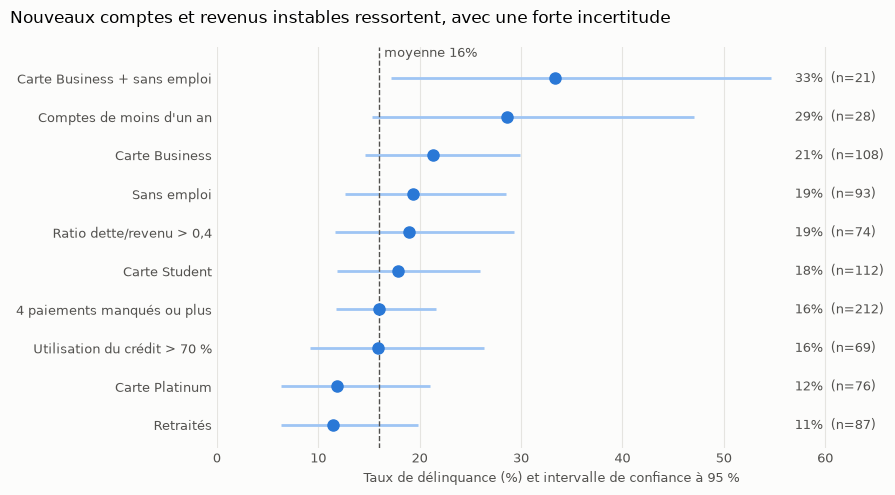

In [2]:
BLUE, MUTED, GRID, SURFACE = "#2a78d6", "#52514e", "#e5e4e0", "#fcfcfb"
plot = seg.iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
ax.errorbar(plot.taux * 100, plot.segment,
            xerr=[(plot.taux - plot.IC95_bas) * 100, (plot.IC95_haut - plot.taux) * 100],
            fmt="o", color=BLUE, ecolor="#9ec5f4", elinewidth=2, capsize=0, markersize=8)
ax.axvline(base * 100, color=MUTED, ls="--", lw=1)
ax.text(base * 100 + 0.5, len(plot) - 0.45, f"moyenne {base:.0%}", color=MUTED, fontsize=9)
for y, (rate, n) in enumerate(zip(plot.taux, plot.clients)):
    ax.text(57, y, f"{rate:.0%}  (n={n})", va="center", fontsize=9, color=MUTED)
ax.set_xlim(0, 66)
ax.set_xlabel("Taux de délinquance (%) et intervalle de confiance à 95 %", color=MUTED, fontsize=9)
ax.tick_params(colors=MUTED, labelsize=9, length=0)
ax.grid(axis="x", color=GRID, lw=0.8)
ax.set_axisbelow(True)
for side in ["top", "right", "left", "bottom"]:
    ax.spines[side].set_visible(False)
ax.set_ylim(-0.6, len(plot) - 0.2)
fig.suptitle("Nouveaux comptes et revenus instables ressortent, avec une forte incertitude",
             x=0.01, ha="left", fontsize=12)
fig.tight_layout()
fig.savefig("segments_risque.png", dpi=150)
plt.show()

### 1.2 Lecture des résultats

- **Comptes de moins d'un an** : 28,6 % de délinquance, soit 1,8 fois la moyenne. Le taux reste élevé à 1 an d'ancienneté (22,2 %), puis redescend. Sur le terrain, c'est la période où le client découvre ses échéances et n'a pas encore d'habitude de paiement.
- **Revenus instables** : les clients sans emploi (19,4 %) et les titulaires de carte Business (21,3 %), typiquement des indépendants ou des petites entreprises aux revenus irréguliers. Le cumul des deux atteint 33 %, soit 2 fois la moyenne (21 clients).
- **Endettement élevé** : un ratio dette/revenu supérieur à 0,4 porte le taux à 18,9 %.
- **Ce qui ne ressort pas** : l'utilisation du crédit et le nombre de paiements manqués, pourtant les deux premiers prédicteurs dans le secteur, n'ont aucun effet visible ici (16 %, comme la moyenne). L'EDA a montré que l'historique de paiement est incohérent dans ce jeu de données.
- **Fiabilité** : tous les intervalles de confiance chevauchent la moyenne de 16 %, et le modèle de la partie 2 n'a pas dépassé un AUC de 0,49. Ces segments sont des **pistes à tester**, pas des certitudes.

### 1.3 Les 3 principaux facteurs de risque

1. **Ancienneté du compte < 1 an** : 28,6 % de délinquance, 1,8 fois la moyenne. Le premier cycle de paiement est la période la plus fragile.
2. **Revenus instables** (sans emploi, carte Business) : 19 à 21 % de délinquance, et jusqu'à 33 % quand les deux se cumulent.
3. **Endettement élevé** (ratio dette/revenu > 0,4) : 18,9 % de délinquance, car la marge de remboursement est réduite.

À ces trois facteurs s'ajoute une condition préalable : l'historique de paiement, normalement le meilleur prédicteur, doit être corrigé dans les données de Geldium avant de pouvoir être exploité.